In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from pysr import PySRRegressor
import matplotlib.pyplot as plt

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
df = pd.read_excel("./banco de dados daniel.xlsx", "Dataset com TS variável")
df = df.drop("Autor", axis=1)
X = df.drop("w (mm)", axis=1)
y = df["w (mm)"]

In [3]:
X = X.rename(columns=lambda c: c.encode("ascii", "ignore").decode("ascii"))
X.columns = [c.replace("(", "").replace(")", "").replace(" ", "_") for c in X.columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

In [4]:
model = PySRRegressor(
    parsimony=0.015,
    maxsize=20,
    maxdepth=6,
    population_size=50,
    ncycles_per_iteration=4000,
    niterations=1500,
    adaptive_parsimony_scaling=100.0,
    deterministic=False,
    parallelism='multithreading',
    progress=True,
    should_optimize_constants=True,
    optimizer_algorithm="BFGS",
    optimizer_nrestarts=5,
    binary_operators=["+", "-", "*", "/", "pow"],
    unary_operators=["sin", "cos", "exp", "log", "sqrt", "square", "abs"],
    constraints={"pow": (-1, 1)},
    weight_optimize=0.005,
)

model.fit(X_train, y_train)

/home/andre/programing/lamfo/ic_andre_rimes/env/lib/python3.10/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 6.220e+05
Progress: 204 / 46500 total iterations (0.439%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.474e-02  0.000e+00  y = 0.26695
3           1.204e-02  1.015e-01  y = Tenso_na_armadura_menos_tension_stiffening_MPa * 0.000...
                                      95397
4           1.087e-02  1.015e-01  y = sqrt(Tenso_na_armadura_menos_tension_stiffening_MPa) *...
                                       0.016919
5           1.024e-02  6.026e-02  y = (Tenso_na_armadura_menos_tension_stiffening_MPa * 0.00...
                                      060318) + 0.10863
6           9.593e-03  6.512e-02  y = sqrt(Distncia_ao_centro_de_gravidade_da_armadura__mm *...
                                       Tenso_na_armadura_menos_tension_stiffening_MPa

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '-', ...]"
,unary_operators,"['sin', 'cos', ...]"
,expression_spec,None
,niterations,1500
,populations,31
,population_size,50
,max_evals,None
,maxsize,20
,maxdepth,6
,warmup_maxsize_by,None


  - outputs/20251001_141047_24sT6u/hall_of_fame.csv


In [5]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

best_eq = model.get_best()
best_equation = best_eq['equation']

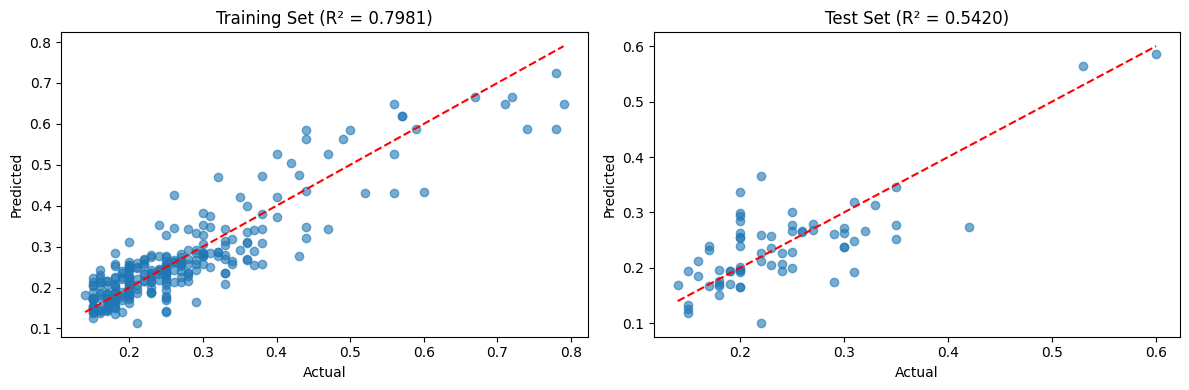

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(y_train, y_pred_train, alpha=0.6)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
ax1.set_xlabel('Actual')
ax1.set_ylabel('Predicted')
ax1.set_title(f'Training Set (R² = {r2_train:.4f})')

ax2.scatter(y_test, y_pred_test, alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title(f'Test Set (R² = {r2_test:.4f})')

plt.tight_layout()
plt.show()

In [7]:
best_eq = model.get_best()
print(f"Best equation: {best_eq['equation']}")
print(f"Complexity: {best_eq['complexity']} nodes")

print("\nFull equations found:")
print(model.equations_[['complexity', 'loss', 'score', 'equation']])

Best equation: (Resistncia__trao_do_concreto_MPa + (Distncia_ao_centro_de_gravidade_da_armadura__mm / (sin(Nmero_de_barras_em_uma_camada) + Resistncia__trao_do_concreto_MPa))) * ((Tenso_na_armadura_menos_tension_stiffening_MPa + Espaamento_entre_as_barras_mm) * 5.0157316e-5)
Complexity: 14 nodes

Full equations found:
    complexity      loss     score  \
0            1  0.014745  0.000000   
1            3  0.012037  0.101469   
2            4  0.010874  0.101542   
3            5  0.008804  0.211190   
4            6  0.008791  0.001432   
5            7  0.007501  0.158695   
6            9  0.005728  0.134842   
7           10  0.004477  0.246533   
8           12  0.003662  0.100380   
9           13  0.003329  0.095336   
10          14  0.002977  0.112003   
11          15  0.002971  0.001874   
12          16  0.002894  0.026380   
13          17  0.002696  0.070927   
14          18  0.002624  0.026801   
15          19  0.002518  0.041135   

                                 

In [8]:
import sympy as sp
from IPython.display import display, Latex

equation_sympy = model.sympy()
equation_latex = sp.latex(equation_sympy)

table_latex = f"""
\\begin{{array}}{{|l|c|}}
\\hline
\\textbf{{Metric}} & \\textbf{{Value}} \\\\
\\hline
\\text{{Equation}} & {equation_latex} \\\\
\\hline
R^2 \\text{{ (Train)}} & {r2_train:.4f} \\\\
\\hline
R^2 \\text{{ (Test)}} & {r2_test:.4f} \\\\
\\hline
\\text{{RMSE (Train)}} & {rmse_train:.4f} \\\\
\\hline
\\text{{RMSE (Test)}} & {rmse_test:.4f} \\\\
\\hline
\\end{{array}}
"""

display(Latex(table_latex))

<IPython.core.display.Latex object>

In [56]:
models_pred_df = pd.read_excel("banco de dados daniel.xlsx", "Modelos normativos e empíricos")
y_pred_total = model.predict(X)

models_pred_df["Symbolic Regression"] = None  
for i in range(len(y_pred_total)): 
    models_pred_df.at[i, "Symbolic Regression"] = y_pred_total[i]

models_pred_df["Symbolic Regression"] = pd.to_numeric(
    models_pred_df["Symbolic Regression"], errors="coerce"
)

wexp_col = "wexp (mm)"
for col in models_pred_df.select_dtypes(include="number").columns:
    if col == wexp_col:
        continue
    models_pred_df[f"{col} / wexp"] = models_pred_df[col] / models_pred_df[wexp_col]

models_pred_df.drop(columns=['wexp (mm)', 'fib Model Code 2010', 'fib Model Code 2020', 'Eurocode 2',
       'NBR 6118 - wk1 - fissuração estabilizada',
       'NBR 6118 - wk2 - fissuração não estabilizada', 'Clark (1956)',
       'Leonhardt (1977)', 'Desayi e Ganesan (1985)', 'Oh e Kang (1987)',
       'Caldas (1997)', 'Gergely e Lutz (1968)', ' b  variável e < 0,6',
       'equação (15) do artigo de Belarbi e Hsu (1994)',
       'Beta conforme Fields e Bischoff (2004)', 'slip de Yuan et al. (2025)',
       'slip de Biscaia e Soares (2020)', 'HistGradientBoosting_TS_var',
       'LGBM_TS_var', 'GradientBoosting_TS_var', 'HistGradientBoosting_sem_TS',
       'LGBM_sem_TS', 'GradientBoosting_sem_TS', 'Symbolic Regression'], inplace=True)

numeric_df = models_pred_df.select_dtypes(include="number")
desc = numeric_df.describe().T
desc["skewness"] = numeric_df.skew()
desc["kurtosis"] = numeric_df.kurtosis()
desc_rounded = desc.round(2).drop(columns=["count"])
desc_rounded

,mean,std,min,25%,50%,75%,max,skewness,kurtosis
fib Model Code 2010 / wexp,0.86,0.28,0.04,0.67,0.83,1.06,1.56,0.09,0.06
fib Model Code 2020 / wexp,0.85,0.25,0.19,0.67,0.85,1.00,1.57,0.30,0.11
Eurocode 2 / wexp,0.91,0.31,0.24,0.72,0.87,1.08,2.02,0.82,1.27
NBR 6118 - wk1 - fissuração estabilizada / wexp,1.11,0.34,0.24,0.88,1.15,1.36,2.01,-0.13,-0.42
NBR 6118 - wk2 - fissuração não estabilizada / wexp,1.25,0.62,0.20,0.84,1.13,1.60,4.54,1.48,4.16
Clark (1956) / wexp,0.94,0.44,0.16,0.60,0.84,1.17,2.19,0.88,0.28
Leonhardt (1977) / wexp,1.36,0.43,0.17,1.08,1.37,1.61,2.41,-0.17,-0.10
Desayi e Ganesan (1985) / wexp,1.16,0.45,0.40,0.79,1.13,1.48,2.36,0.40,-0.68
Oh e Kang (1987) / wexp,0.88,0.30,0.25,0.65,0.88,1.11,1.55,-0.11,-0.74
Caldas (1997) / wexp,0.81,0.22,0.32,0.68,0.79,0.92,1.68,0.73,1.50
